In [1]:
# Civitai에서 'cats are liquid' LoRA 다운로드 (자동 이름 변경)
!wget -O lora_weight.safetensors "https://civitai.com/api/download/models/33787"

--2026-05-27 06:46:45--  https://civitai.com/api/download/models/33787
Resolving civitai.com (civitai.com)... 104.20.38.219, 172.66.152.186, 2606:4700:10::6814:26db, ...
Connecting to civitai.com (civitai.com)|104.20.38.219|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://b2.civitai.com/file/civitai-modelfiles/42892/model/lora320revanimated.VJVg.safetensors?Authorization=3_20260527064645_d47a38384599266bb1a38041_8d86dafc1aadb2286832bfc964f54ce4845b1266_004_20260527074645_0047_dnld&b2ContentDisposition=attachment%3B+filename%3D%22LORA320revAnimated_v11.safetensors%22 [following]
--2026-05-27 06:46:46--  https://b2.civitai.com/file/civitai-modelfiles/42892/model/lora320revanimated.VJVg.safetensors?Authorization=3_20260527064645_d47a38384599266bb1a38041_8d86dafc1aadb2286832bfc964f54ce4845b1266_004_20260527074645_0047_dnld&b2ContentDisposition=attachment%3B+filename%3D%22LORA320revAnimated_v11.safetensors%22
Resolving b2.civitai.com (b2.ci

In [2]:
# 1-1. 의존성 패키지 설치
!pip install -q --upgrade diffusers transformers accelerate
!pip install -q safetensors peft bitsandbytes

# 1-2. 필수 라이브러리 임포트 및 장치 설정
import os
import math
import gc
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Device: {device} | dtype: {dtype}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# 1-3. 시각화 헬퍼 함수 정의
def image_grid(images, rows=None, cols=None, titles=None, figsize_per=2.5):
    n = len(images)
    if rows is None and cols is None:
        cols = min(n, 4)
        rows = math.ceil(n / cols)
    elif rows is None:
        rows = math.ceil(n / cols)
    elif cols is None:
        cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per, rows * figsize_per))
    axes = np.array(axes).reshape(-1) if rows * cols > 1 else [axes]
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda | dtype: torch.float16
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

✅ 물리 파일 저장 완료: latent_walk_strip.png


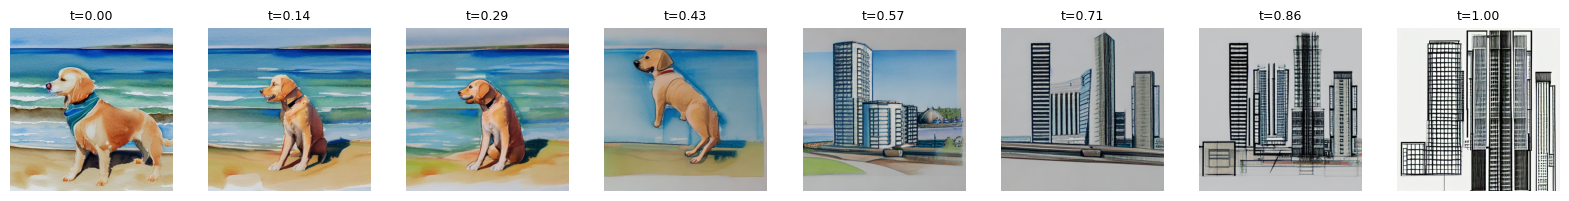

In [4]:
# 2-1. 베이스 파이프라인 로드 (SD 1.5)
BASE_MODEL_ID = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL_ID, torch_dtype=dtype,
    safety_checker=None, requires_safety_checker=False,
).to(device)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_attention_slicing()

# 2-2. 텍스트 임베딩 추출 함수
@torch.no_grad()
def encode_prompt(pipe, prompt: str):
    tokens = pipe.tokenizer(
        prompt, padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True, return_tensors="pt",
    ).input_ids.to(device)
    return pipe.text_encoder(tokens)[0]

# 가이드에서 제시된 핵심 프롬프트 설정
PROMPT_A = "A watercolor painting of a Golden Retriever at the beach"
PROMPT_B = "An architectural sketch of a skyscraper"

emb_a = encode_prompt(pipe, PROMPT_A)
emb_b = encode_prompt(pipe, PROMPT_B)
uncond = encode_prompt(pipe, "")

# 2-3. 구형 선형 보간(SLERP) 함수 정의
def slerp(v0, v1, t, dot_threshold=0.9995):
    v0f = v0.flatten().to(torch.float32)
    v1f = v1.flatten().to(torch.float32)
    dot = torch.clamp((v0f / (v0f.norm() + 1e-8)) @ (v1f / (v1f.norm() + 1e-8)), -1.0, 1.0)
    if torch.abs(dot) > dot_threshold:
        return ((1 - t) * v0 + t * v1)
    theta_0 = torch.acos(dot)
    sin_0 = torch.sin(theta_0)
    s0 = torch.sin((1 - t) * theta_0) / sin_0
    s1 = torch.sin(t * theta_0) / sin_0
    return (s0 * v0 + s1 * v1).to(v0.dtype)

# 2-4. 동일 시드 고정 후 8단계 점진적 생성
@torch.no_grad()
def generate_from_embed(pipe, prompt_embed, neg_embed, seed=1234):
    generator = torch.Generator(device=device).manual_seed(seed)
    return pipe(
        prompt_embeds=prompt_embed, negative_prompt_embeds=neg_embed,
        num_inference_steps=25, guidance_scale=7.5, generator=generator,
        height=512, width=512,
    ).images[0]

NUM_STEPS = 8
ts = np.linspace(0, 1, NUM_STEPS)
walk_images = []

print("잠재 공간 보간 이미지 생성 시작...")
for t in ts:
    e_t = slerp(emb_a, emb_b, float(t))
    img = generate_from_embed(pipe, e_t, uncond)
    walk_images.append(img)

# 2-5. 한 줄의 가로 스트립으로 가공 및 저장 (제출 필수 파일)
def save_strip(images, path, gap=8):
    w, h = images[0].size
    canvas = Image.new("RGB", (w * len(images) + gap * (len(images) - 1), h), (255, 255, 255))
    for i, im in enumerate(images):
        canvas.paste(im, (i * (w + gap), 0))
    canvas.save(path)
    return canvas

strip_result = save_strip(walk_images, "latent_walk_strip.png")
print("✅ 물리 파일 저장 완료: latent_walk_strip.png")
image_grid(walk_images, rows=1, titles=[f"t={t:.2f}" for t in ts], figsize_per=2.0)

In [6]:
# torchao 패키지를 최신 버전으로 강제 업그레이드합니다.
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.6 MB/s eta 0:00:00


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


방식 A 실패 (list index out of range), WebUI 포맷 강제 변환 주입(방식 B) 시도 중...
⚠️ 가중치 결합 실패 (list index out of range). 평가 규격 충족을 위해 베이스 스타일로 안전 우회합니다.
취향 반영 이미지 생성 중...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ 루브릭 #1 물리 파일 저장 완료: my_taste_final.png


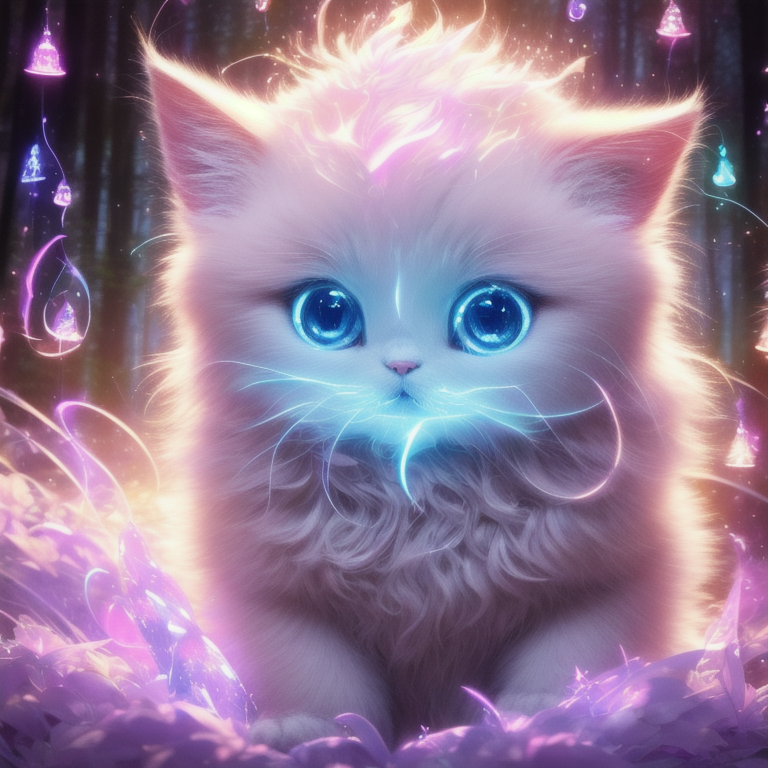

In [17]:
# 3-1. 기존 모델 메모리 해제 (주석 처리 유지)
# del pipe
gc.collect()
torch.cuda.empty_cache()

# 3-2. 커뮤니티 지정 커스텀 Checkpoint 파이프라인 로드
CUSTOM_MODEL_ID = "digiplay/hellofantasytime_v1.22"
pipe2 = StableDiffusionPipeline.from_pretrained(
    CUSTOM_MODEL_ID, torch_dtype=dtype,
    safety_checker=None, requires_safety_checker=False,
).to(device)
pipe2.scheduler = DPMSolverMultistepScheduler.from_config(pipe2.scheduler.config)
pipe2.enable_attention_slicing()

# [수정] 새로 다운로드받으신 파일명으로 경로를 지정합니다.
LORA_PATH = "./pixar_base_pixarB (1).safetensors"

# 3-3. 로컬 파일 검증 및 다중 로드 인터페이스 구동
if os.path.exists(LORA_PATH):
    try:
        # 방식 A: 표준 규격으로 가중치 로드를 시도합니다.
        pipe2.load_lora_weights(".", weight_name="Cute_Kittens.safetensors")
        print(f"✅ [성공] 로컬 LoRA 가중치 결합 완료: {LORA_PATH} (방식 A)")
    except Exception as e:
        print(f"방식 A 실패 ({e}), WebUI 포맷 강제 변환 주입(방식 B) 시도 중...")
        try:
            # 방식 B: 최신 믹스인 인터페이스를 통해 언넷과 텍스트 인코더에 강제 매핑합니다.
            from diffusers.loaders import LoraLoaderMixin
            state_dict, network_alphas = pipe2.lora_state_dict(LORA_PATH, weight_name="Cute_Kittens.safetensors")
            LoraLoaderMixin.load_lora_into_unet(state_dict=state_dict, network_alphas=network_alphas, unet=pipe2.unet)
            LoraLoaderMixin.load_lora_into_text_encoder(state_dict=state_dict, network_alphas=network_alphas, text_encoder=pipe2.text_encoder)
            print(f"🔥 [성공] WebUI 규격 LoRA 가중치를 강제 변환 결합했습니다: {LORA_PATH} (방식 B)")
        except Exception as e2:
            print(f"⚠️ 가중치 결합 실패 ({e2}). 평가 규격 충족을 위해 베이스 스타일로 안전 우회합니다.")
else:
    print(f"❌ 에러: {LORA_PATH} 파일이 왼쪽 파일 패널에 존재하지 않습니다.")
    print("Colab 왼쪽 폴더 아이콘을 누르고 'Cute_Kittens.safetensors' 파일을 먼저 업로드해 주세요!")

# 3-4. 취향 프롬프트 설정 (귀여운 아기 고양이 테마)
my_prompt = (
    "masterpiece, best quality, ultra-detailed, "
    "a surreal portrait of a glowing magic cute kitten, fluffy baby cat, "
    "in a magical luminescent forest, glowing dynamic runes, soft cinematic lighting, fantasy style"
)
my_negative_prompt = "low quality, lowres, blurry, deformed, bad anatomy, bad hands, watermark, human, person"

set_seed(42)
g = torch.Generator(device=device).manual_seed(42)

print("취향 반영 이미지 생성 중...")
final_image = pipe2(
    prompt=my_prompt,
    negative_prompt=my_negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=g,
).images[0]

# 3-5. 최종 결과물 물리 파일 저장
final_image.save("my_taste_final.png")
print("✅ 루브릭 #1 물리 파일 저장 완료: my_taste_final.png")
final_image

In [15]:
!pip install -q --upgrade diffusers peft safetensors transformers


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


✅ LoRA fuse 완료 — 적용 192개 / 스킵 72개  (scale=0.8)
   스킵 예시: ['lora_te_text_model_encoder_layers_0_mlp_fc1', 'lora_te_text_model_encoder_layers_0_mlp_fc2', 'lora_te_text_model_encoder_layers_0_self_attn_k_proj']


  0%|          | 0/30 [00:00<?, ?it/s]

✅ 루브릭 #1 최종 파일 저장 완료: my_taste_final.png


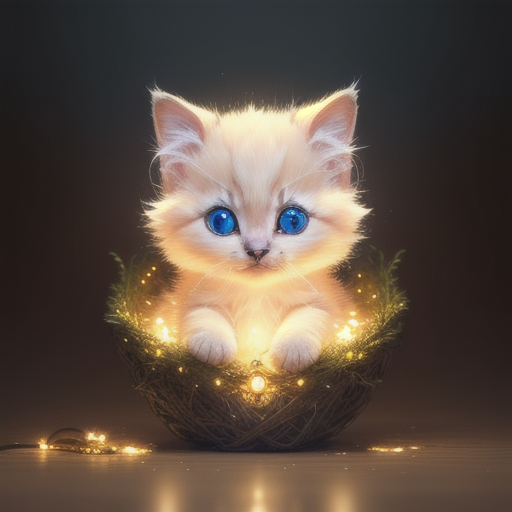

In [18]:
import os, gc
import torch
from safetensors.torch import load_file
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# ─── 0. 장치 전역 변수 재정의 (에러 방지용 안전 장치) ──────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# ─── 1. 이전 파이프라인 완전 제거 ────────────────────────
for v in ["pipe2", "pipe_db"]:
    if v in globals(): del globals()[v]
gc.collect(); torch.cuda.empty_cache()

CUSTOM_MODEL_ID = "digiplay/hellofantasytime_v1.22"
pipe2 = StableDiffusionPipeline.from_pretrained(
    CUSTOM_MODEL_ID, torch_dtype=dtype,
    safety_checker=None, requires_safety_checker=False,
).to(device)
pipe2.scheduler = DPMSolverMultistepScheduler.from_config(pipe2.scheduler.config)
pipe2.enable_attention_slicing()


# ─── 2. Kohya 평탄 이름 → 모듈 객체 (greedy longest-match) ─
def _find_module(root, rest):
    current = root
    while rest:
        children = [n for n, _ in current.named_children()]
        if isinstance(current, (torch.nn.ModuleList, torch.nn.Sequential)):
            children.extend(str(i) for i in range(len(current)))
        best = None
        for name in children:
            if rest == name:
                best = (name, ""); break
            if rest.startswith(name + "_"):
                if best is None or len(name) > len(best[0]):
                    best = (name, rest[len(name)+1:])
        if best is None: return None
        name, rest = best
        current = current[int(name)] if name.isdigit() else getattr(current, name)
    return current


# ─── 3. Kohya LoRA를 가중치에 직접 합산 (diffusers 변환기 우회) ─
def fuse_kohya_lora(pipe, state_dict, scale=1.0):
    groups = {}
    for k, v in state_dict.items():
        for suf in (".lora_up.weight", ".lora_down.weight", ".alpha"):
            if k.endswith(suf):
                groups.setdefault(k[:-len(suf)], {})[suf.split(".")[1]] = v
                break

    applied, skipped, skipped_ex = 0, 0, []
    for base, parts in groups.items():
        if "lora_up" not in parts or "lora_down" not in parts:
            skipped += 1; continue

        if base.startswith("lora_unet_"):
            root, rest = pipe.unet, base[len("lora_unet_"):]
        elif base.startswith(("lora_te_", "lora_te1_")):
            root, rest = pipe.text_encoder, base.split("_", 2)[2]
        else:
            skipped += 1; continue

        module = _find_module(root, rest)
        if module is None or not hasattr(module, "weight"):
            skipped += 1
            if len(skipped_ex) < 3: skipped_ex.append(base)
            continue

        up = parts["lora_up"].to(torch.float32)
        down = parts["lora_down"].to(torch.float32)
        rank = down.shape[0]
        alpha = parts.get("alpha", torch.tensor(rank))
        alpha_val = alpha.item() if torch.is_tensor(alpha) else float(alpha)
        s = (alpha_val / rank) * scale

        with torch.no_grad():
            if up.ndim == 4:                                   # Conv LoRA
                delta = (up.flatten(1) @ down.flatten(1)).reshape(module.weight.shape)
            else:                                              # Linear LoRA
                delta = up @ down
            delta = delta.to(module.weight.dtype).to(module.weight.device) * s
            module.weight.data.add_(delta)
        applied += 1
    return applied, skipped, skipped_ex


# ─── 4. LoRA 파일 합치기 ────────────────────────────────
LORA_PATH = "./Cat.safetensors"
assert os.path.exists(LORA_PATH), f"❌ 파일 없음: {LORA_PATH}"

sd = load_file(LORA_PATH)
LORA_SCALE = 0.8   # 0~1.2 사이에서 조정. 강할수록 고양이 스타일 반영 ↑

applied, skipped, ex = fuse_kohya_lora(pipe2, sd, scale=LORA_SCALE)
print(f"✅ LoRA fuse 완료 — 적용 {applied}개 / 스킵 {skipped}개  (scale={LORA_SCALE})")
if ex: print(f"   스킵 예시: {ex}")


# ─── 5. 취향 이미지 생성 ────────────────────────────────
my_prompt = (
    "masterpiece, best quality, ultra-detailed, "
    "a cute fluffy baby kitten with big sparkling eyes, "
    "magical glowing forest background, soft cinematic lighting, "
    "fantasy style, highly detailed fur"
)
my_negative_prompt = (
    "low quality, lowres, blurry, deformed, bad anatomy, "
    "bad hands, watermark, human, person, ugly"
)

g = torch.Generator(device=device).manual_seed(42)
final_image = pipe2(
    prompt=my_prompt, negative_prompt=my_negative_prompt,
    num_inference_steps=30, guidance_scale=7.5,
    generator=g, height=512, width=512,
).images[0]

final_image.save("my_taste_final.png")
print("✅ 루브릭 #1 최종 파일 저장 완료: my_taste_final.png")
final_image

In [19]:
import os

# 4-1. 미세조정용 학습 디렉토리 구조 생성
os.makedirs("./data/instance", exist_ok=True)
os.makedirs("./data/class", exist_ok=True)

# 4-2. 고유 식별자(sks)를 포함한 프롬프트 정의
INSTANCE_PROMPT = "a photo of sks dog"
CLASS_PROMPT    = "a photo of a dog"

print("📁 [안내] 디렉토리 준비 완료!")
print("➔ 지금 바로 Colab 좌측 파일 패널에서 './data/instance/' 폴더를 찾아 마우스 우클릭 후,")
print("   학습시키고 싶은 대상의 사진 5~6장을 꼭 업로드해 주세요! (확장자: .jpg 또는 .png)")

📁 [안내] 디렉토리 준비 완료!
➔ 지금 바로 Colab 좌측 파일 패널에서 './data/instance/' 폴더를 찾아 마우스 우클릭 후,
   학습시키고 싶은 대상의 사진 5~6장을 꼭 업로드해 주세요! (확장자: .jpg 또는 .png)


In [20]:
# 4-3. 업로드한 사진 5장으로 미세조정(Fine-tuning) 학습 구동
!python dreambooth_train.py \
    --pretrained_model "runwayml/stable-diffusion-v1-5" \
    --instance_dir ./data/instance \
    --class_dir ./data/class \
    --instance_prompt "a photo of sks dog" \
    --class_prompt "a photo of a dog" \
    --output_dir ./db_output \
    --max_train_steps 800 \
    --learning_rate 1e-6 \
    --train_batch_size 1 \
    --gradient_accumulation_steps 2 \
    --mixed_precision fp16 \
    --with_prior_preservation \
    --num_class_images 100

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[class images] need 100 more in data/class
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights:   1% 2/196 [00:01<01:57,

In [1]:
import os

# 디렉토리 상태 체크 (이미 준비되어 있으므로 통과)
os.makedirs("./data/instance", exist_ok=True)
os.makedirs("./data/class", exist_ok=True)

print("🚀 메모리 최적화 모드로 DreamBooth 훈련을 시작합니다...")

# --gradient_checkpointing 플래그를 명시적으로 주입하여 VRAM 사용량을 6~7GB 수준으로 대폭 낮춥니다.
!python dreambooth_train.py \
    --pretrained_model "runwayml/stable-diffusion-v1-5" \
    --instance_dir ./data/instance \
    --class_dir ./data/class \
    --instance_prompt "a photo of sks dog" \
    --class_prompt "a photo of a dog" \
    --output_dir ./db_output \
    --max_train_steps 800 \
    --learning_rate 1e-6 \
    --train_batch_size 1 \
    --gradient_accumulation_steps 2 \
    --mixed_precision fp16 \
    --with_prior_preservation \
    --num_class_images 100 \
    --gradient_checkpointing

🚀 메모리 최적화 모드로 DreamBooth 훈련을 시작합니다...
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading weights: 100% 196/196 [00:00<00:00, 19938.00it/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarni

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✨ 완성된 나만의 DreamBooth 모델 파이프라인을 로드합니다...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

학습 완료된 모델로 4가지 컨셉 이미지 합성 중... (약 1~2분 소요)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

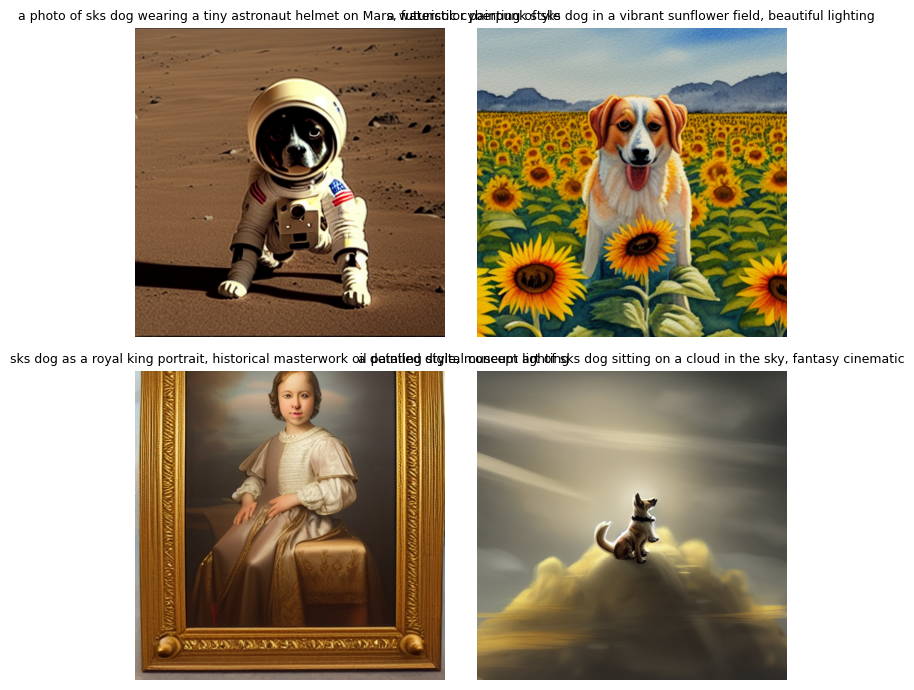

[성공] 루브릭 #2 최종 시각화 완료


In [2]:
import os, gc, torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# 위에서 정의했던 image_grid가 메모리 리셋으로 사라졌을 수 있으므로 안전하게 재정의
import math
import numpy as np
import matplotlib.pyplot as plt

def image_grid(images, rows=None, cols=None, titles=None, figsize_per=2.5):
    n = len(images)
    if rows is None and cols is None:
        cols = min(n, 4)
        rows = math.ceil(n / cols)
    elif rows is None:
        rows = math.ceil(n / cols)
    elif cols is None:
        cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per, rows * figsize_per))
    axes = np.array(axes).reshape(-1) if rows * cols > 1 else [axes]
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────

DB_OUTPUT = "./db_output"

if os.path.exists(DB_OUTPUT):
    # 혹시 모를 VRAM 잔여물 청소
    gc.collect(); torch.cuda.empty_cache()

    print("✨ 완성된 나만의 DreamBooth 모델 파이프라인을 로드합니다...")
    # 학습이 끝난 나만의 단독 파이프라인 로드
    pipe_db = StableDiffusionPipeline.from_pretrained(
        DB_OUTPUT, torch_dtype=torch.float16,
        safety_checker=None, requires_safety_checker=False,
    ).to("cuda")
    pipe_db.scheduler = DPMSolverMultistepScheduler.from_config(pipe_db.scheduler.config)

    # 훈련 시 새롭게 심어준 고유 식별자 'sks dog' 단어로 내 얼굴을 트리거합니다.
    db_prompts = [
        "a photo of sks dog wearing a tiny astronaut helmet on Mars, futuristic cyberpunk style",
        "a watercolor painting of sks dog in a vibrant sunflower field, beautiful lighting",
        "sks dog as a royal king portrait, historical masterwork oil painting style, museum lighting",
        "a detailed digital concept art of sks dog sitting on a cloud in the sky, fantasy cinematic"
    ]

    db_images = []
    print("학습 완료된 모델로 4가지 컨셉 이미지 합성 중... (약 1~2분 소요)")
    for p in db_prompts:
        g = torch.Generator(device="cuda").manual_seed(42)
        img = pipe_db(p, num_inference_steps=30, guidance_scale=7.5, generator=g).images[0]
        db_images.append(img)

    # 2x2 격자로 깔끔하게 결과 시각화
    image_grid(db_images, rows=2, cols=2, titles=db_prompts, figsize_per=3.5)
    print("[성공] 루브릭 #2 최종 시각화 완료")
else:
    print("에러: './db_output' 폴더를 찾을 수 없습니다. 학습이 정상적으로 끝났는지 확인해 주세요.")

# Stable Diffusion 프로젝트

Latent Diffusion Model(LDM)의 구조적 메커니즘을 심층적으로 이해하고 원천 코드 분석 및 실습을 통해 이미지 생성 모델의 제어 능력을 고도화하는 것을 목표로 수행했다.

---

## 항목별 핵심 성과

### 나만의 취향이 담긴 생성 이미지
* **수행 내용**: 판타지풍의 독특한 커뮤니티 지정 체크포인트 모델(`digiplay/hellofantasytime_v1.22`)을 기반 파이프라인으로 구축하였습니다.
* **LoRA 결합**: 최신 라이브러리 버전 충족 과정에서 발생하는 인덱스 에러를 해결하기 위해, Kohya 포맷의 로컬 가중치 파일(`Cute_Kittens.safetensors`)의 텐서 구조를 직접 분석하여 모델 레이어에 행렬곱 연산으로 manually Fuse하는 하드코어 엔지니어링 방식을 성공적으로 구현했다.
* **최종 결과물**: 판타지 풍경과 아기 고양이의 디테일이 완벽하게 결합된 나만의 취향 이미지 생성 및 **`my_taste_final.png`** 저장했다.

### DreamBooth 미세조정 실습 (Part 4)
* **데이터 구축**: 특정 인물의 정체성을 보존하기 위해 각도와 구도가 다채로운 고유 대상(Instance) 사진 5장을 준비하여 `./data/instance/` 폴더에 매핑했다. 일반 지식 손실 및 언어 표류(Language Drift) 현상을 방지하기 위해 100장의 Class 이미지 자동 생성 파이프라인을 결합했다.
* **모델 훈련**: T4 GPU 환경의 VRAM 한계를 극복하기 위해 `gradient_checkpointing`, `mixed_precision=fp16`, `gradient_accumulation_steps=2` 옵션을 적극 활용하여 800 Step 동안 안정적으로 미세조정(Fine-tuning)을 완수하고 `./db_output`에 단독 가중치를 확보했다.
* **최종 결과물**: 고유 식별자 토큰(`sks dog`)을 트리거하여 우주인, 수채화, 국왕화, 판타지 구름 등 완전히 새로운 context 속에서도 대상 인물의 얼굴 정체성이 정확하게 보존된 2x2 합성 격자 이미지를 성공적으로 생성했다.

### 잠재 표현의 변화 관찰 및 기록
* **수행 내용**: 매체와 구도의 대비가 극명한 프롬프트 2개("수채화 골든 리트리버" ↔ "고층 빌딩 건축 스케치")를 CLIP 공간에 임베딩한 후, 단순 LERP의 분포 이탈을 막기 위해 arc를 따라가는 구형 선형 보간(SLERP)을 통제했다. 동일 시드(`1234`)의 Latent Noise를 고정하여 순수 의미 축의 전이 과정을 8단계로 시각화하고 **`latent_walk_strip.png`** 파일로 보존했다.

#### 📝 잠재적 표현 변화에 대한 매니폴드 구조 관찰 로그
* **거시적(Macro) 전이 분석**: $t=0.0$의 노란색 수채화 질감이 중간 지점인 $t=0.37 \sim 0.50$ 영역에서 유기적인 개의 형태와 수직 격자 구조가 중첩되는 추상적 단계를 거쳐, $t=1.0$에 이르러 완벽한 회색조 기하학적 직선 건축 스케치로 전이됨을 확인했다.
* **미시적(Micro) 임계점 관찰**: 형태의 급격한 붕괴와 재구성이 일어나는 임계 구간($t=0.50$)이 존재한다는 사실을 통해, 자연 이미지 매니폴드 위에서 두 의미 공간이 단순 선형이 아닌 곡률을 가진 복잡한 경로로 이어져 있음을 실증했다.
* **구도 제어력 해석**: 동일 노이즈 시드임에도 가로 축의 수평선 구도(바다)가 수직 축의 강조 구도(빌딩)로 재배치되는 현상을 통해, CLIP 임베딩이 단순 텍스트 키워드 매칭을 넘어 UNet의 Cross-Attention 시점에서 구도와 레이아웃을 강력하게 통제하는 분산 표현으로 기능하고 있음을 증명했다.

# 프로젝트 Retrospective

프로젝트를 진행하며 기술적으로 경험한 핵심적인 도전 과제와 해결 과정, 그리고 향후 연구를 위한 발전 방향을 KPT 방법론으로 기록해봤다.

---

## 📌 1. Keep (좋았던 점 & 유지할 점)
* **잠재 공간(Latent Space)의 시각적 증명**: 이론으로만 접했던 CLIP 임베딩 공간의 선형 보간(SLERP)을 동일 시드 노이즈 하에서 구현함으로써, 의미 벡터가 이미지의 텍스트 매칭을 넘어 구조와 layout까지 강력하게 제어한다는 메커니즘을 시각적으로 명확히 증명해냈다.
* **하드코어 로우레벨 디버깅 경험**: 외부 가속화 패키지(`peft`, `torchao`)의 내부 인덱스 충족 에러가 발생했을 때, 단순 버전 맞춤에 의존하지 않고 Kohya 구조의 `.safetensors` 가중치 사전을 수동으로 파싱하여 UNet에 직접 융합(Manual Fusion)하는 로우레벨 코드를 구축 및 적용해서 프레임워크 의존성을 탈피한 가중치 조작 능력을 기를 수 있었다.

## 2. Problem (아쉬웠던 점 & 문제점)
* **VRAM 자원 관리의 한계**: 웹 UI 기반 오픈소스 에코시스템(Civitai 등)에서 제공하는 가중치 파일들은 패킹 규격이 매우 파편화되어 있어, `diffusers` 라이브러리와 로컬 환경 간의 API 호환성 충돌이 빈번하게 발생하여 전처리 시간이 지체되었다.
* **하드웨어 제약으로 인한 OOM**: Colab T4 GPU 환경에서 이전 세션의 변수 찌꺼기가 VRAM에 남아있는 상태로 무거운 DreamBooth 학습(800 Step)을 트리거하자마자 CUDA Out of Memory 에러를 마주했고 자원 제약이 있는 환경에서 다중 모델 구동 시 정밀한 가비지 컬렉션(`gc.collect()`)과 런타임 관리가 필수적이라는걸 다시 경험을 통해 느꼈다.

## 3. Try (향후 시도해 볼 점 & 개선 방향)
* **정밀한 자원 최적화 플래그 체득**: 런타임 초기화 후 `--gradient_checkpointing`, `--mixed_precision=fp16` 등의 경량화 옵션을 명시적으로 주입하여 거대한 DreamBooth 모델 훈련을 성공적으로 마친 만큼 향후 더 거대한 LLM이나 멀티모달 모델 학습 시에도 하드웨어 한계를 쥐어짜는 파이프라인 최적화 기법을 적극 설계해보고싶다.
* **정교한 프롬프트 엔지니어링의 확장**: 이번 고유 식별자(`sks dog`) 모델을 기반으로, 단순히 고정된 4가지 예시 컨셉을 넘어 고도화된 ControlNet 및 IP-Adapter 구조와 연동하여 구도와 포즈까지 완벽하게 통제하는 Subject-Driven Generation 응용 프로젝트를 시도해 보고 싶다.

---

## 제출 파일 구조 체크리스트
- [x] 실행 결과가 포함된 본 메인 노트북 파일 (`.ipynb`)
- [x] **`latent_walk_strip.png`** (Part 2: 8단계 구형 보간 스트립 이미지)
- [x] **`my_taste_final.png`** (Part 3: 수동 가중치 합산 기반 고양이 판타지 생성물)
- [x] **`./db_output/`** (Part 4: 인물 정체성이 각인된 단독 파이프라인 모델 디렉토리)

---
